# final working

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
df=pd.read_csv("data/sortedWithoutVifNIC.csv")

In [3]:
df.head(1)

,Date,Open,High,Low,Close,Qty,Turnover,EPS,PE,RSI9,...,MACDHist,BollingerUpper,BollingerMiddle,BollingerLower,ATR,Closediff,year,month,day,dayofweek
0,2016-10-17,660.0,660.0,647.0,651.0,5758,3758521.0,17.94,36.287625,5.357143,...,5.916752,671.74543,610.2,548.65457,12.6,-9.0,2016,10,17,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1919 entries, 0 to 1918
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             1919 non-null   object 
 1   Open             1919 non-null   float64
 2   High             1919 non-null   float64
 3   Low              1919 non-null   float64
 4   Close            1919 non-null   float64
 5   Qty              1919 non-null   int64  
 6   Turnover         1919 non-null   float64
 7   EPS              1919 non-null   float64
 8   PE               1919 non-null   float64
 9   RSI9             1919 non-null   float64
 10  RSI14            1919 non-null   float64
 11  RSI25            1919 non-null   float64
 12  MACD             1919 non-null   float64
 13  MACDSignal       1919 non-null   float64
 14  MACDHist         1919 non-null   float64
 15  BollingerUpper   1919 non-null   float64
 16  BollingerMiddle  1919 non-null   float64
 17  BollingerLower

In [5]:
df.drop("Turnover", axis=1, inplace=True)

df['Date'] = pd.to_datetime(df['Date']) 

df.set_index('Date', inplace=True)
# df = df.apply(lambda x: x.astype(str).str.replace(',', '', regex=True))

df['pchange'] = df['Close'].pct_change()*100
df.isnull().sum()

Open               0
High               0
Low                0
Close              0
Qty                0
EPS                0
PE                 0
RSI9               0
RSI14              0
RSI25              0
MACD               0
MACDSignal         0
MACDHist           0
BollingerUpper     0
BollingerMiddle    0
BollingerLower     0
ATR                0
Closediff          0
year               0
month              0
day                0
dayofweek          0
pchange            1
dtype: int64

In [6]:
#removing null values by bfill:
df.bfill(inplace=True)

# df.sort_values(by=["Date"], inplace=True, ascending=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1919 entries, 2016-10-17 to 2025-02-20
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Open             1919 non-null   float64
 1   High             1919 non-null   float64
 2   Low              1919 non-null   float64
 3   Close            1919 non-null   float64
 4   Qty              1919 non-null   int64  
 5   EPS              1919 non-null   float64
 6   PE               1919 non-null   float64
 7   RSI9             1919 non-null   float64
 8   RSI14            1919 non-null   float64
 9   RSI25            1919 non-null   float64
 10  MACD             1919 non-null   float64
 11  MACDSignal       1919 non-null   float64
 12  MACDHist         1919 non-null   float64
 13  BollingerUpper   1919 non-null   float64
 14  BollingerMiddle  1919 non-null   float64
 15  BollingerLower   1919 non-null   float64
 16  ATR              1919 non-null   float64
 

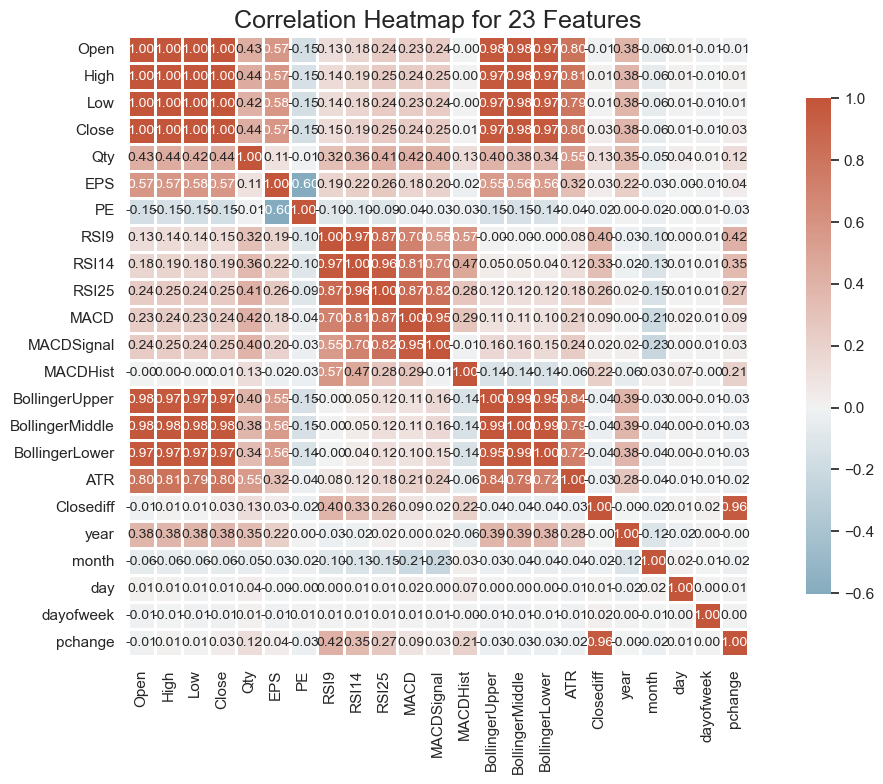

In [8]:
# Step 1: Calculate the correlation matrix
import seaborn as sns
corr_matrix = df.corr()

# Step 2: Plot the heatmap using Seaborn
plt.figure(figsize=(12, 8))  # Adjust size as per your dataset

# Create a custom diverging color palette
sns.set(style="white")  # Set style for better presentation
cmap = sns.diverging_palette(230, 20, as_cmap=True)  # Diverging color map

# Create heatmap with annotation and color intensity
sns.heatmap(corr_matrix, 
            annot=True,             # Annotate the values
            cmap=cmap,              # Use diverging palette for better clarity
            center=0,               # Center the colors around 0
            square=True,            # Square-shaped grid
            linewidths=0.8,         # Line width between cells
            fmt=".2f",              # Formatting for correlation values
            cbar_kws={"shrink": 0.8},  # Adjust color bar size
            annot_kws={"size": 10})    # Font size of annotations

# Step 3: Title and display the plot
plt.title(f'Correlation Heatmap for {len(df.columns)} Features', fontsize=18)
plt.tight_layout()  # Make sure everything fits
plt.show()

In [9]:
# to check numeric ways of this data:
# correlation_matrix = df.corr(numeric_only=True)
# print(correlation_matrix)

In [10]:

df.describe()

,Open,High,Low,Close,Qty,EPS,PE,RSI9,RSI14,RSI25,...,BollingerUpper,BollingerMiddle,BollingerLower,ATR,Closediff,year,month,day,dayofweek,pchange
count,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,...,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000,1919.000000
mean,568.243200,574.946795,559.053830,565.995154,72199.473163,30.132501,32.350906,47.947353,48.174678,48.220497,...,604.856618,567.126264,529.395910,16.545667,-0.148775,2020.465868,6.534653,15.682647,2.395518,-0.008636
std,193.030373,195.024173,188.625419,191.073708,85038.827424,14.008393,48.426220,17.303152,14.705279,12.078001,...,202.692506,189.004027,179.800511,7.873286,11.971208,2.437703,3.546756,8.761399,2.036784,2.007748
min,295.000000,303.000000,285.000000,298.000000,60.000000,1.780000,9.367337,4.122138,8.300548,15.137615,...,318.617976,312.450000,278.590077,4.709079,-188.500000,2016.000000,1.000000,1.000000,0.000000,-24.753775
25%,411.000000,415.000000,406.000000,410.050000,17448.500000,17.940000,14.665401,36.455206,38.661607,40.680003,...,443.391313,411.725000,386.213798,10.706225,-5.100000,2018.000000,3.000000,8.000000,1.000000,-1.005576
50%,498.000000,505.000000,490.000000,497.000000,44108.000000,34.560000,18.719690,47.132630,47.602449,48.190789,...,530.189526,500.100000,458.144456,14.611313,-1.000000,2021.000000,7.000000,16.000000,2.000000,-0.170358
75%,730.000000,736.550000,720.100000,725.100000,91554.000000,40.220000,24.671145,58.373252,56.463793,54.915309,...,787.246234,724.445000,681.418007,21.264004,4.000000,2023.000000,10.000000,23.000000,3.000000,0.816883
max,1080.000000,1085.000000,1046.000000,1073.000000,751075.000000,60.770000,285.955056,95.133500,91.880660,86.866562,...,1107.163095,1036.595000,1005.221541,46.924015,77.000000,2025.000000,12.000000,31.000000,6.000000,10.000000


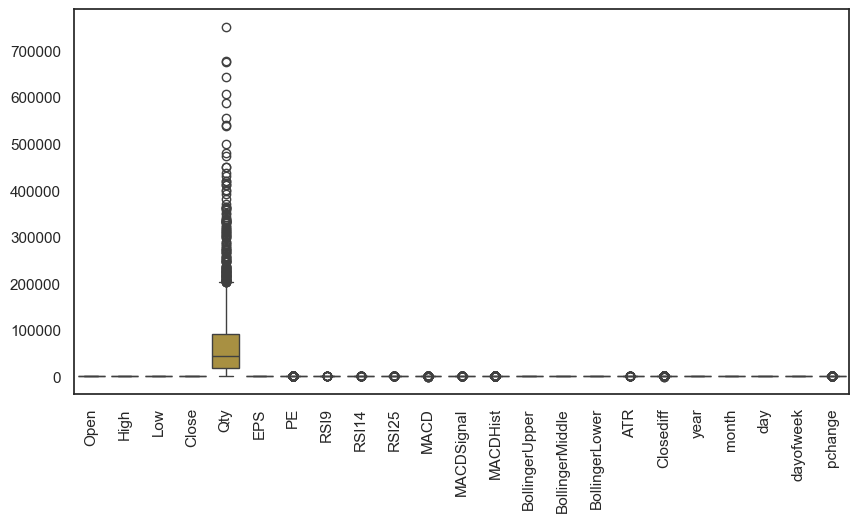

In [11]:
#Checking Outliers by box plot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.boxplot(data=df)
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.show()

* To remove outliers, we can use min max scaler to to range the values between certain values , also we use clip it using IQR and there are also other ways to remove ouliers

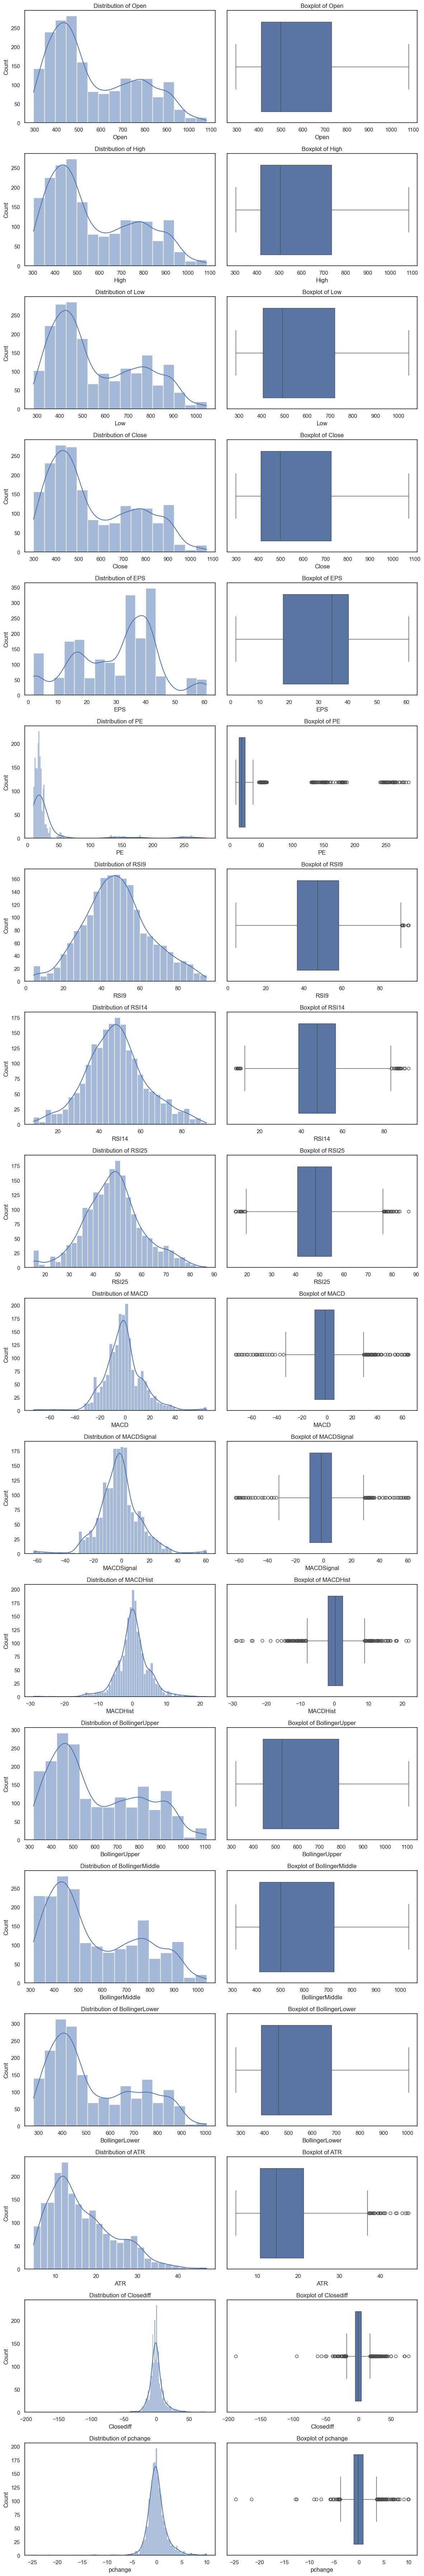

In [12]:
# Calculate rows needed based on the number of columns
numerical_data = df.select_dtypes(include=['float64'])
n_cols = len(numerical_data.columns)
n_rows = n_cols

# Adjust figsize dynamically
plt.figure(figsize=(12, 4 * n_rows))

for i, col in enumerate(numerical_data.columns):
    # Create a subplot for the distribution plot
    plt.subplot(n_rows, 2, 2 * i + 1)
    # sns.histplot(numerical_data[col], kde=True, bins=30)  # Updated to use sns.histplot
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
     # Create a subplot for the boxplot
    plt.subplot(n_rows, 2, 2 * i + 2)
    sns.boxplot(x=numerical_data[col])
    plt.title(f'Boxplot of {col}')

# Adjustjustment on  layout to prevent overlap
plt.tight_layout()
plt.show()

In [13]:
# def find_outliers_iqr_multiple_columns(df,columns):
#     """
#     Identify outliers in multiple specified columns of a data frame using the IQR method.
#     """
#     outliers_summary = {}

#     for column in columns:

#         percentile25 = df[column].quantile(0.25)
#         percentile75 = df[column].quantile(0.75)
#         iqr = percentile75 - percentile25
#         lower_limit = percentile25 - 1.5 * iqr
#         upper_limit = percentile75 + 1.5 * iqr


#         lower_outliers = df[df[column] < lower_limit]
#         upper_outliers = df[df[column] > upper_limit]

#         outliers_summary[column] = {
#             'lower_outliers_count': len(lower_outliers),
#             'upper_outliers_count': len(upper_outliers),
#             'lower_limit': lower_limit,
#             'upper_limit': upper_limit
#         }

#     return outliers_summary
# columns = df.select_dtypes(include=['float64', 'int64'])
# outliers_summary = find_outliers_iqr_multiple_columns(df, columns)


# for column, summary in outliers_summary.items():
#     print(f"\nColumn: {column}")
#     print(f"Lower Outliers Count: {summary['lower_outliers_count']}")
#     print(f"Upper Outliers Count: {summary['upper_outliers_count']}")
#     print(f"Lower Limit: {summary['lower_limit']}")
#     print(f"Upper Limit: {summary['upper_limit']}")

In [14]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# Check for outliers in stock prices
for col in df:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col} - Outliers Found: {len(outliers)}")

Open - Outliers Found: 0
High - Outliers Found: 0
Low - Outliers Found: 0
Close - Outliers Found: 0
Qty - Outliers Found: 139
EPS - Outliers Found: 0
PE - Outliers Found: 193
RSI9 - Outliers Found: 12
RSI14 - Outliers Found: 36
RSI25 - Outliers Found: 63
MACD - Outliers Found: 95
MACDSignal - Outliers Found: 82
MACDHist - Outliers Found: 134
BollingerUpper - Outliers Found: 0
BollingerMiddle - Outliers Found: 0
BollingerLower - Outliers Found: 0
ATR - Outliers Found: 27
Closediff - Outliers Found: 163
year - Outliers Found: 0
month - Outliers Found: 0
day - Outliers Found: 0
dayofweek - Outliers Found: 0
pchange - Outliers Found: 116


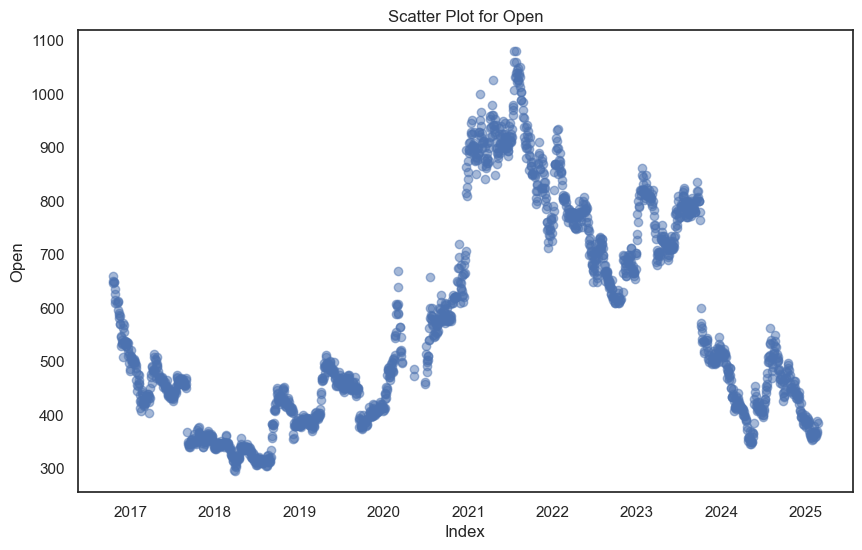

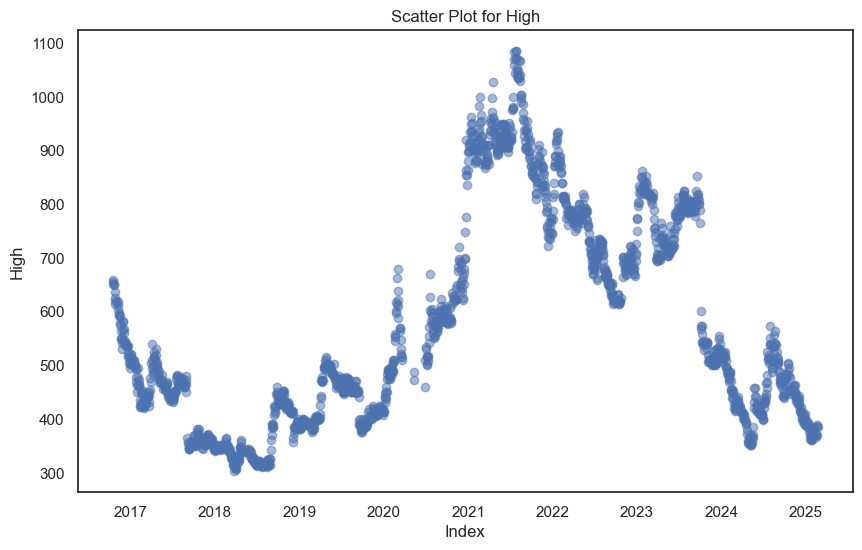

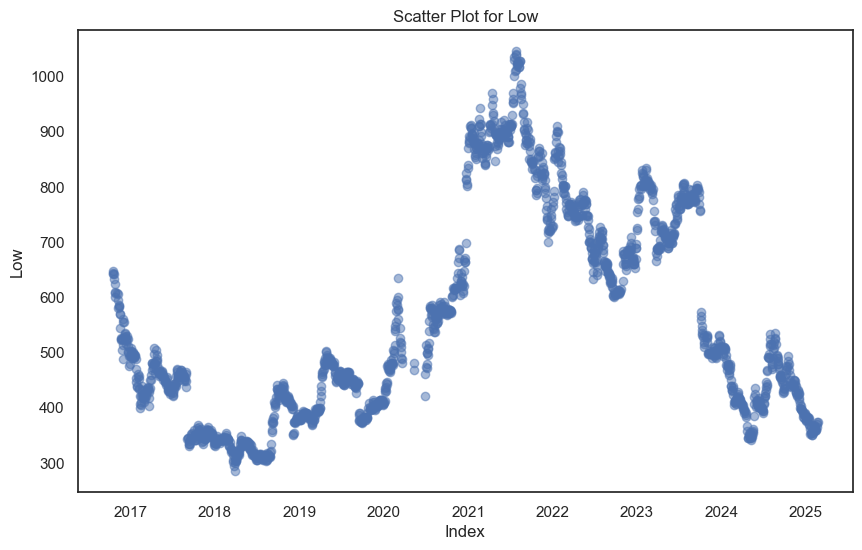

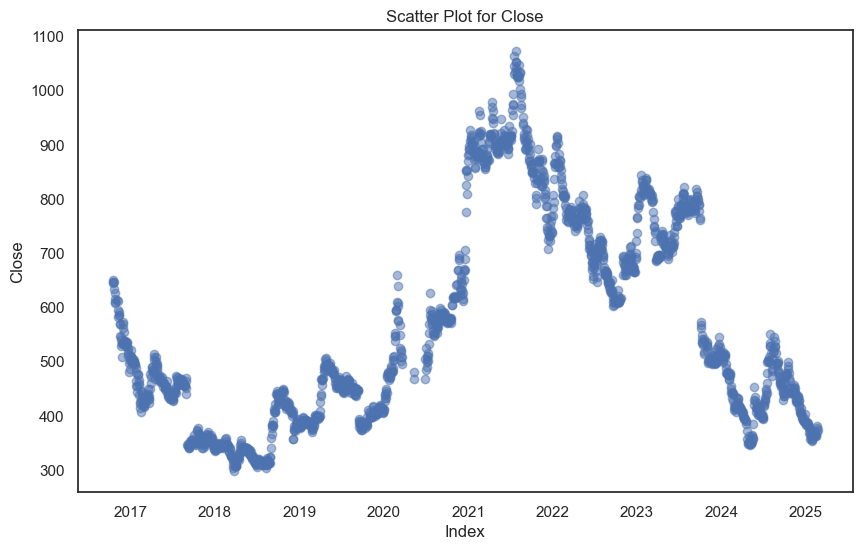

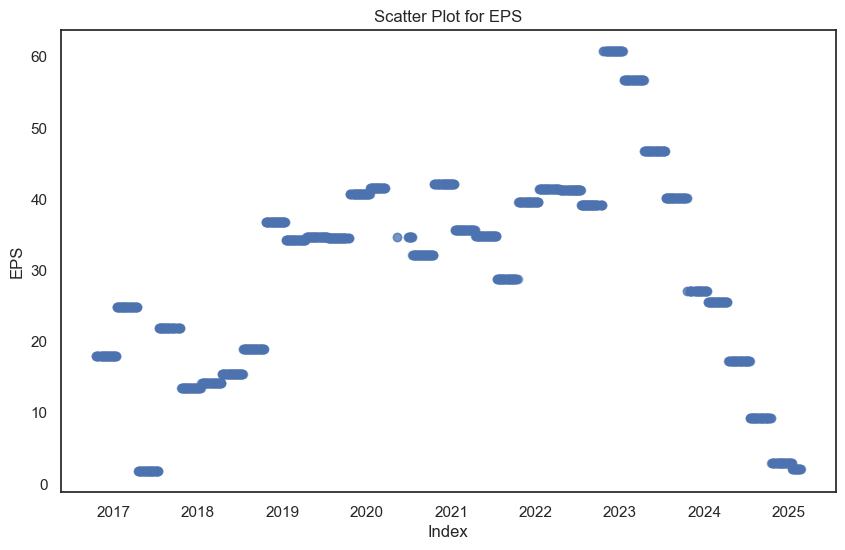

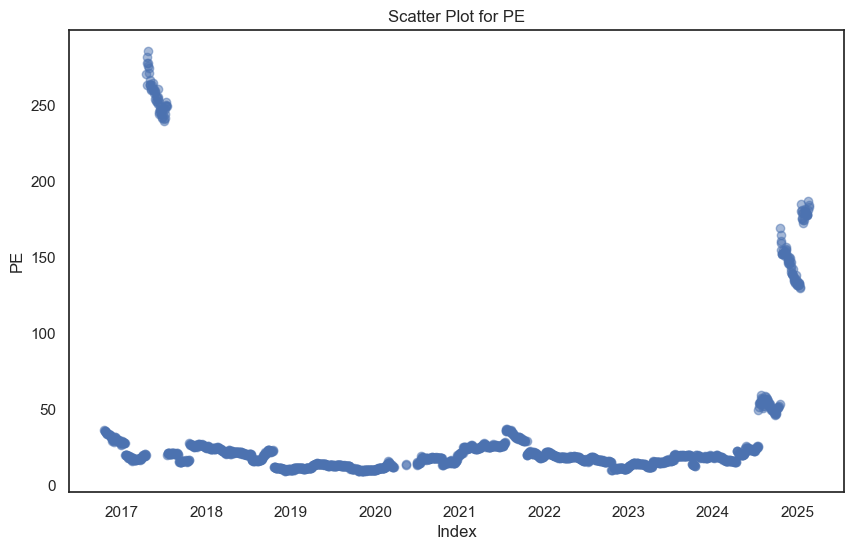

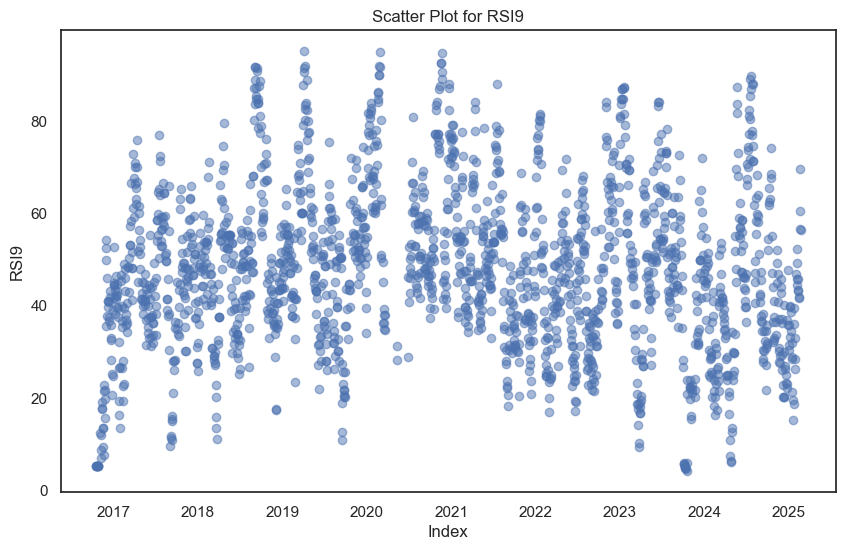

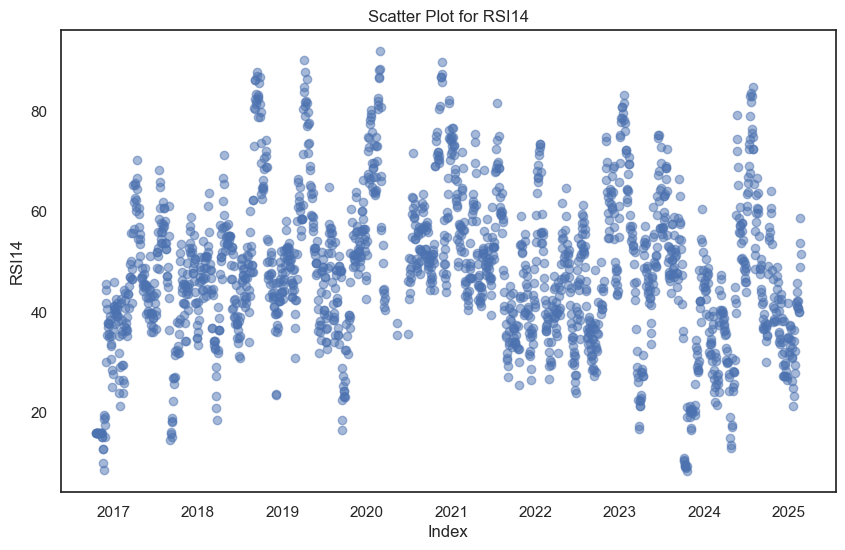

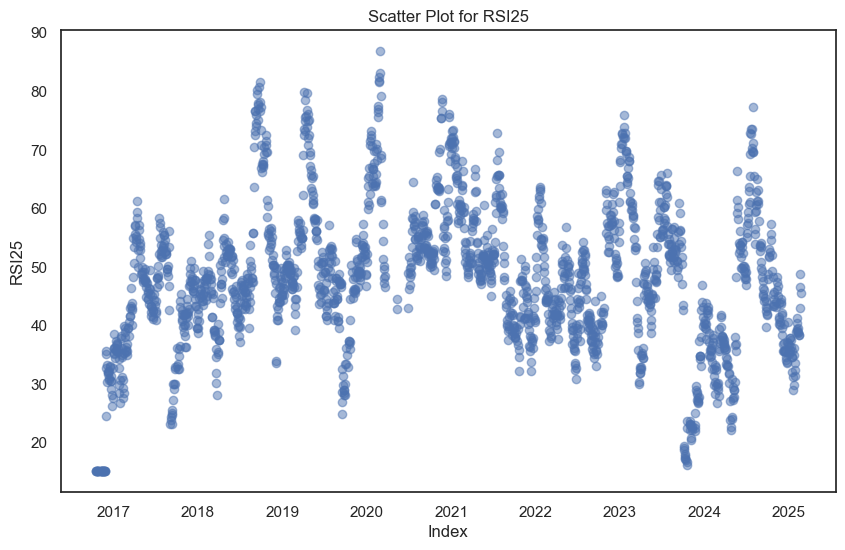

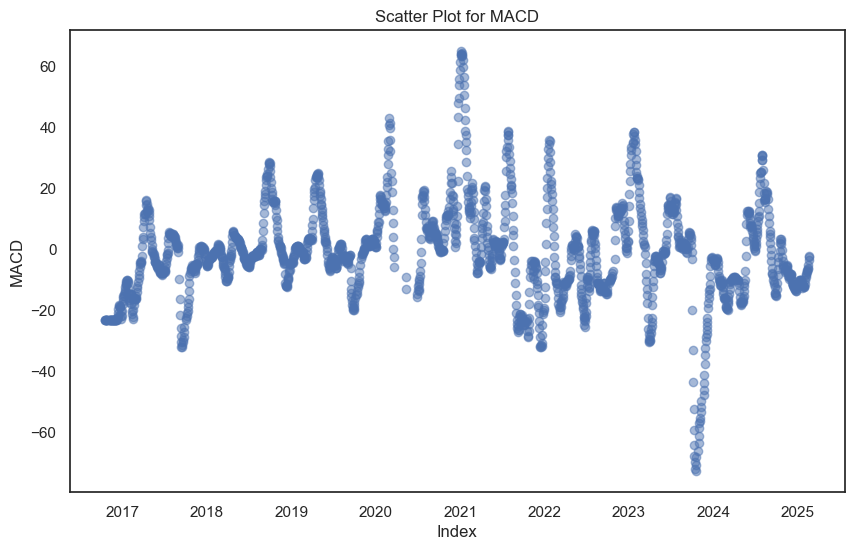

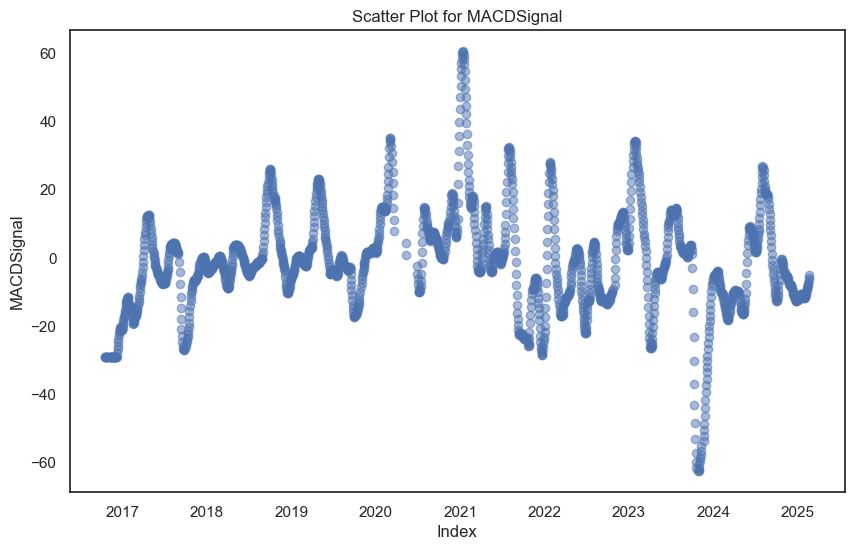

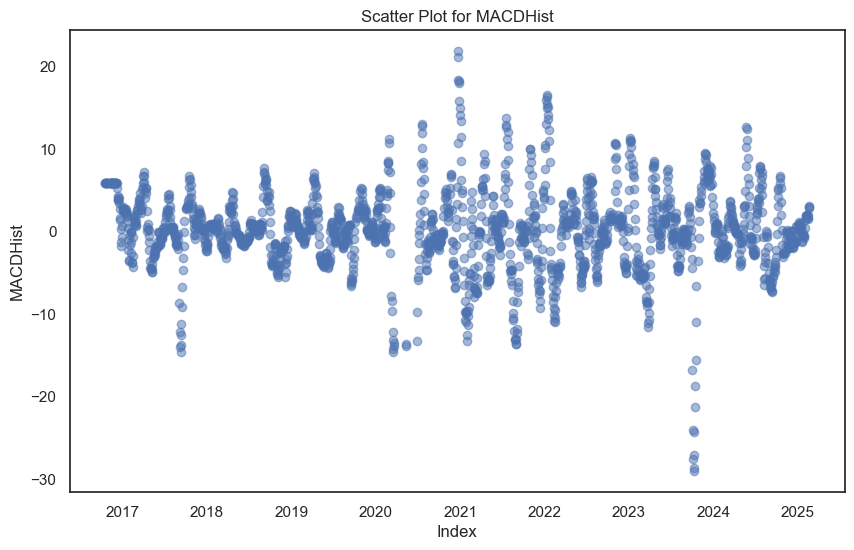

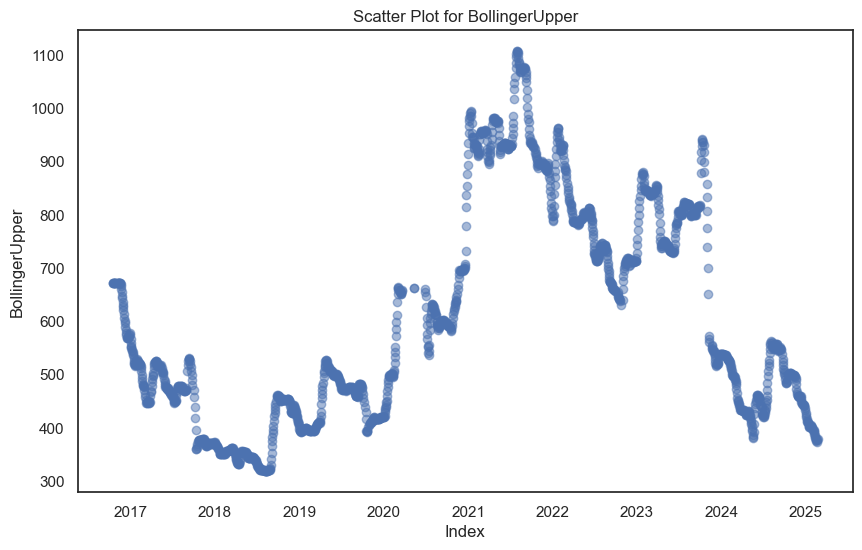

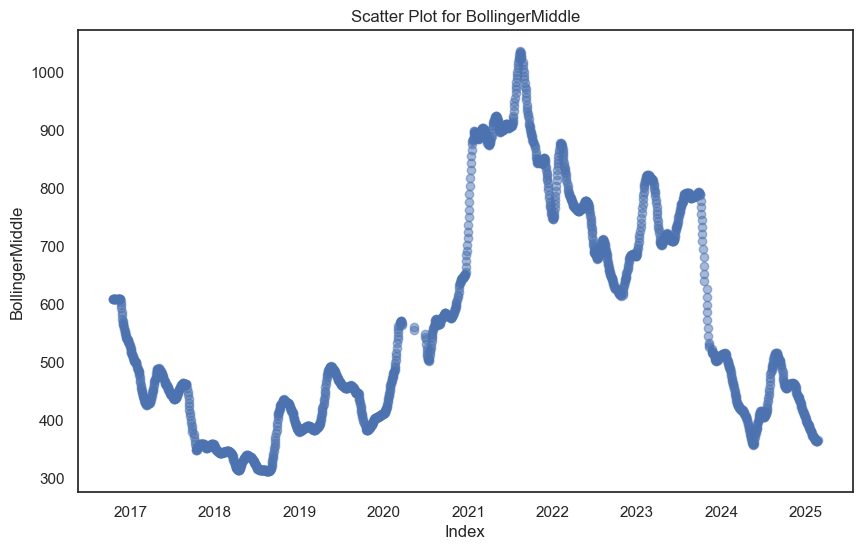

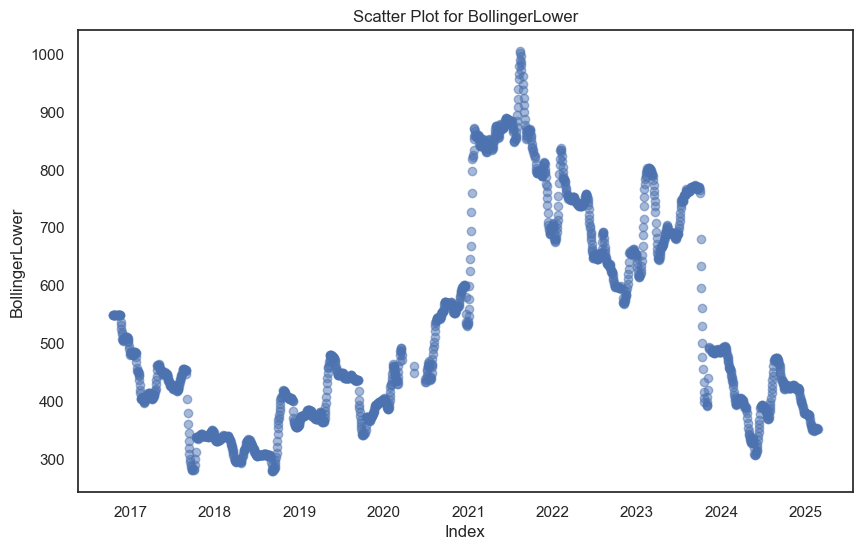

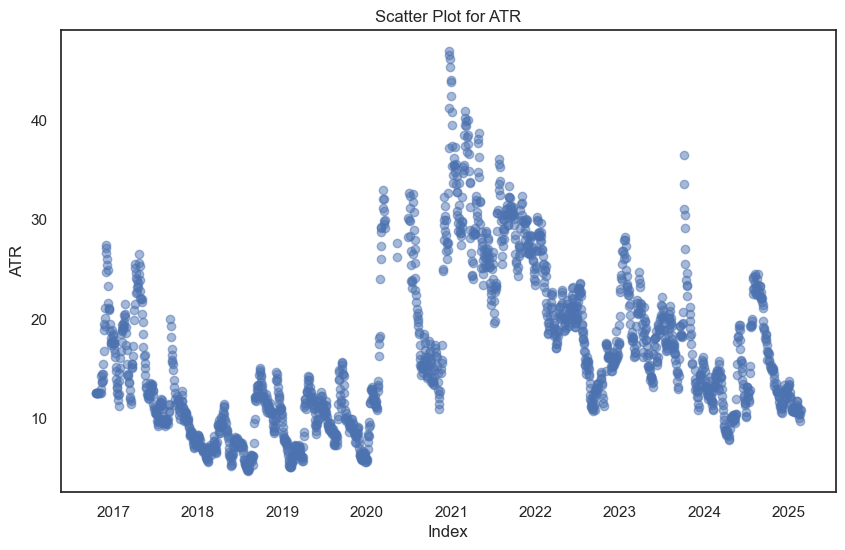

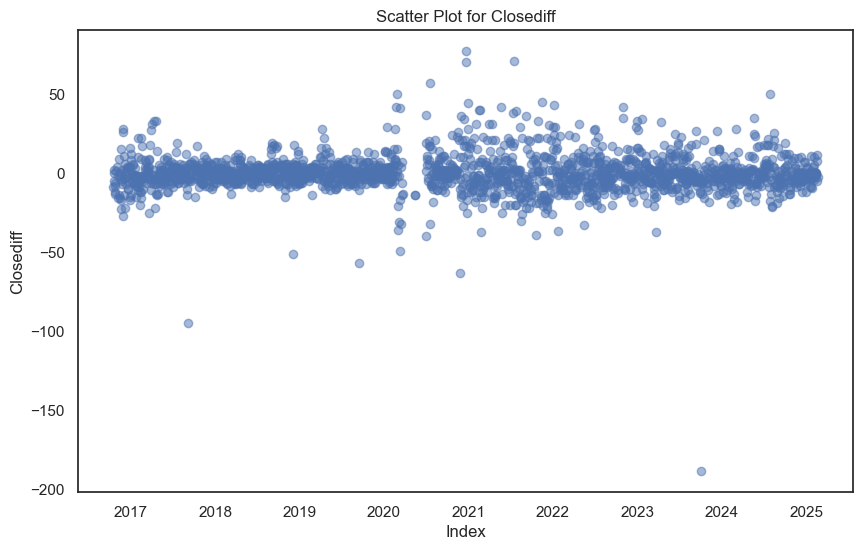

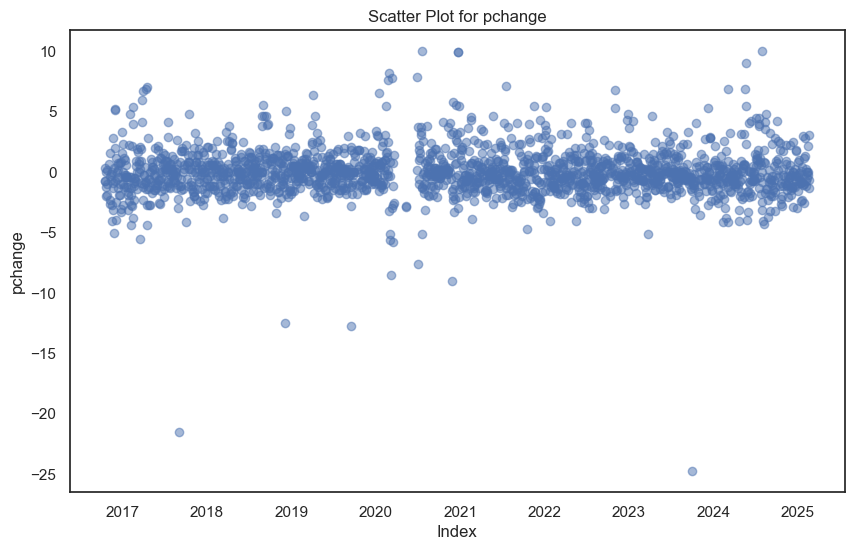

In [15]:
import matplotlib.pyplot as plt

# Plot scatter plot for each numerical column to check for outliers
for column in numerical_data.columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(df.index, df[column], alpha=0.5)
    plt.title(f'Scatter Plot for {column}')
    plt.xlabel('Index')
    plt.ylabel(column)
    plt.show()

In [16]:
#removing outliers

# for col in df:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     df[col] = df[col].clip(lower_bound, upper_bound)

#note: as data is taken from authenticated source, so outliers are not removed because it might have some important information.

In [17]:
# #checking outliers after removing it from above code:
# def detect_outliers_iqr(data, column):
#     Q1 = data[column].quantile(0.25)
#     Q3 = data[column].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
#     return outliers

# # Check for outliers in stock prices
# for col in df:
#     outliers = detect_outliers_iqr(df, col)
#     print(f"{col} - Outliers Found: {len(outliers)}")

#note: not checked as outliers are not removed

In [18]:
#after removing outliers, checking box plot again:

# plt.figure(figsize=(10, 5))
# sns.boxplot(data=df)
# plt.xticks(rotation=90)  # Rotate x-axis labels for readability
# plt.show()

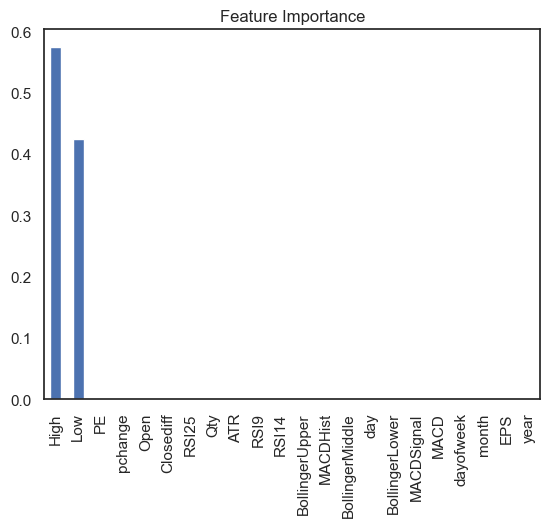

In [19]:
#checking feature imortance:
from sklearn.ensemble import RandomForestRegressor

# Select numerical columns
features = df.columns.drop(['Close'])
X = df[features]
y = df['Close']

# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get feature importance
importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance")
plt.show()


This code is used when you want to analyze which factors influence the stock closing price and build a predictive model using Random Forest Regression.

In [20]:
import numpy as np
import pandas as pd
from pandas.plotting import lag_plot
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

In [21]:
close = df['Close']
result = seasonal_decompose(close, model='additive', period=30)

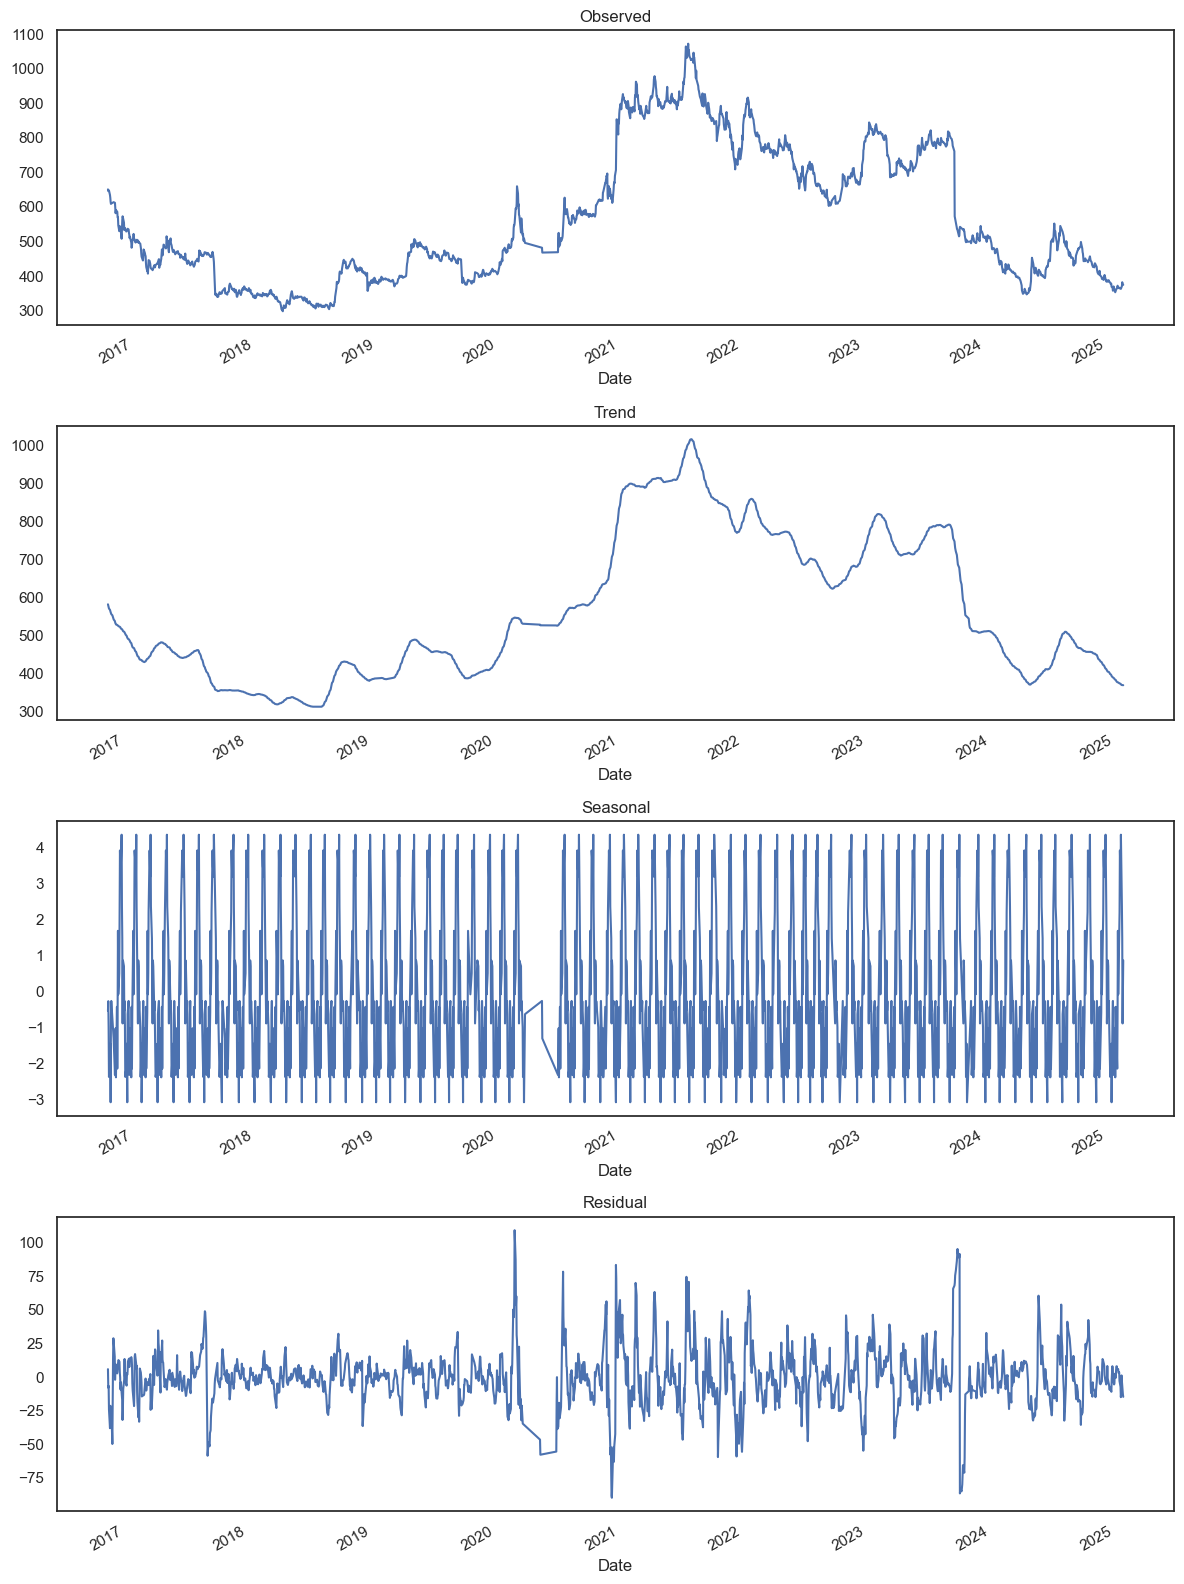

In [22]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 16))
result.observed.plot(ax=ax1)
ax1.set_title('Observed')
result.trend.plot(ax=ax2)
ax2.set_title('Trend')
result.seasonal.plot(ax=ax3)
ax3.set_title('Seasonal')
result.resid.plot(ax=ax4)
ax4.set_title('Residual')
plt.tight_layout()
plt.show()

*  Interpretation of Each Component
* 1) Observed Plot (Top Graph)
*  Represents the raw time series data.

* We see an overall trend + seasonal variations (ups and downs).
* There are fluctuations indicating price movements over time.
* 2) Trend Component (Second Graph)
*  Shows the long-term movement in the data (upward/downward trends).

* There was an uptrend from 2020 to 2022, followed by a downtrend.
* This is useful for detecting if the data follows a structural pattern over time.
* * A strong trend component suggests ARIMA or LSTM might be useful.
* 3) Seasonal Component (Third Graph)
*  Captures repeating patterns at regular intervals.

* The data exhibits strong seasonality, with repeating cycles.
* There’s a disruption around 2021, possibly due to external events (e.g., market crashes, missing data).
* If seasonality is present, SARIMA (Seasonal ARIMA) or LSTMs with periodic inputs could be useful.
* 4) Residual Component (Fourth Graph)
* Represents random noise (unpredictable movements).

* Large residual spikes indicate periods of high volatility.
* If residuals are randomly distributed, the model successfully captures trend & seasonality.
* If residuals show patterns, the model might need improvement.

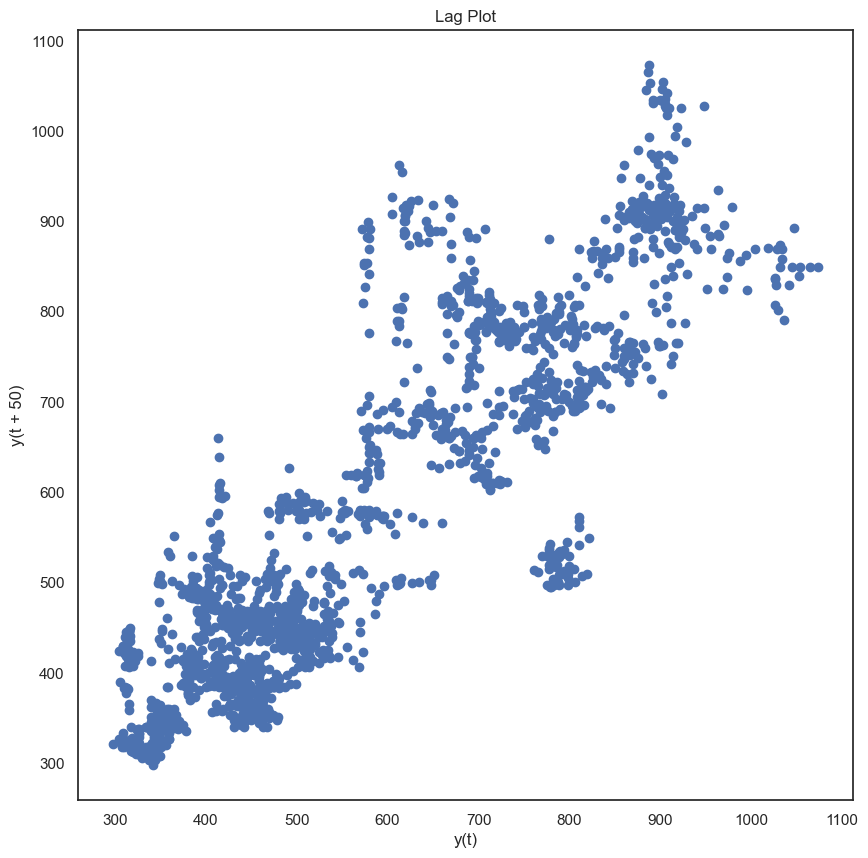

In [23]:
#lag plot
plt.figure(figsize=(10, 10))
lag_plot(close,lag=50) #check lag values at different steps to decide time-steps ie taking prev days values
plt.title('Lag Plot')
plt.show()

In [24]:
# We have not introduced ACF and PACF plots .
#plot of Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF)

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
# plot_acf(close, ax=ax1, lags=100)
# plot_pacf(close, ax=ax2, lags=100)
# plt.tight_layout()
# plt.show()

* Since ACF shows long-term dependence, use at least 60+ timesteps.
* Scaling is required to improve convergence.
### Observation:
* The ACF plot shows strong autocorrelation across all lags (gradual decline).
* This suggests a non-stationary time series (likely a trend or seasonality).
* To make the series stationary, differencing may be needed.


* ACF Analysis (Top Graph)
* Strong autocorrelation at all lags (slow decay) → Suggests a trend (non-stationary).
* Solution: Apply differencing (d=1) and recheck ACF.
* PACF Analysis (Bottom Graph)
* Strong spike at lag 1, then quick drop → Suggests an AR(1) process.
* Solution: Try ARIMA(1,1,0) after differencing.

In [25]:
#breaking into year monnth day and dayofweek
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['dayofweek'] = df.index.dayofweek

<Axes: xlabel='year'>

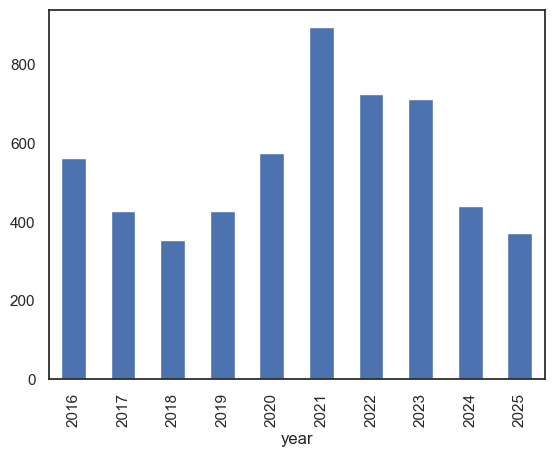

In [26]:
###################
# Yearly Close of nic

df.groupby('year')['Close'].mean().plot.bar()

<Axes: xlabel='month'>

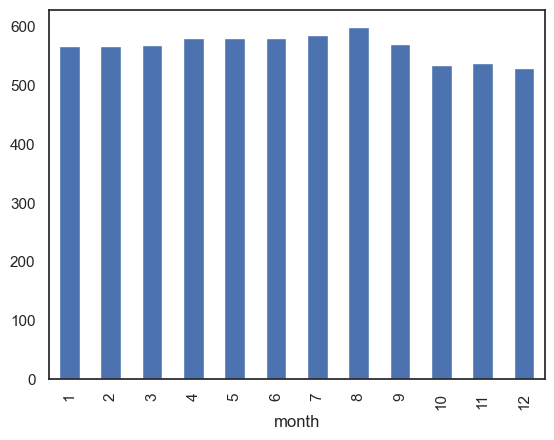

In [27]:
df.groupby('month')['Close'].mean().plot.bar()

<Axes: xlabel='day'>

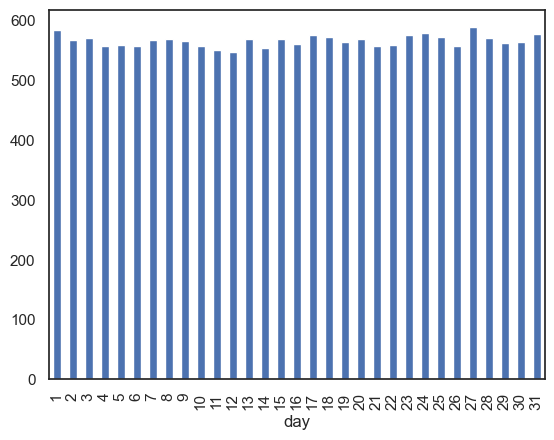

In [28]:
df.groupby('day')['Close'].mean().plot.bar()

<Axes: xlabel='dayofweek'>

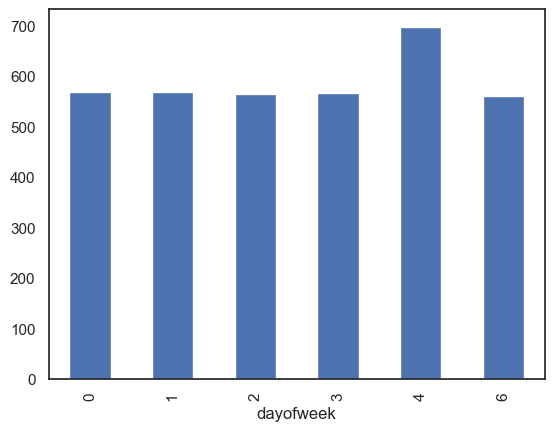

In [29]:
df.groupby('dayofweek')['Close'].mean().plot.bar()

In [30]:
df.head(1)

,Open,High,Low,Close,Qty,EPS,PE,RSI9,RSI14,RSI25,...,BollingerUpper,BollingerMiddle,BollingerLower,ATR,Closediff,year,month,day,dayofweek,pchange
Date,,,,,,,,,,,,,,,,,,,,,
2016-10-17,660.0,660.0,647.0,651.0,5758,17.94,36.287625,5.357143,15.841584,15.137615,...,671.74543,610.2,548.65457,12.6,-9.0,2016,10,17,0,-0.768049


In [31]:
df.drop(['year', 'month', 'day', 'dayofweek'], axis=1, inplace=True)

In [32]:
#data split

In [33]:
# Ensure all  columns are present (adjust if needed)
feature_columns = df.columns # Your 8 features
data = df[feature_columns].values
feature_columns,len(feature_columns)

(Index(['Open', 'High', 'Low', 'Close', 'Qty', 'EPS', 'PE', 'RSI9', 'RSI14',
        'RSI25', 'MACD', 'MACDSignal', 'MACDHist', 'BollingerUpper',
        'BollingerMiddle', 'BollingerLower', 'ATR', 'Closediff', 'pchange'],
       dtype='object'),
 19)

### yaha samn same............................................................................

In [34]:
# Set random seed
random_seed = 42
np.random.seed(random_seed)
train_size = int(len(df) * 0.9)  # 9_0% train

test_size = len(df) - train_size # 10% test




X_train, X_test = (
    data[:train_size], 
    data[train_size:train_size + test_size]
    # X[train_size + val_size:]
)
y_train, y_test = (
   data[:train_size], 
   data[train_size:train_size + test_size]
    # y[train_size + val_size:]
)


In [35]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1727, 19), (192, 19), (1727, 19), (192, 19))

In [36]:
# Normalize Featuree
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))


X_train_scaled = scaler.fit_transform(X_train) 
# X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test )

y_train_scaled = scaler.transform(y_train)
# y_val_scaled = scaler.transform(y_val)
y_test_scaled = scaler.transform(y_test)

In [37]:
def create_sequences(x, y, n_steps):
    X_seq, y_seq = [], []
    for i in range(n_steps, len(y)):  # Ensure `y[i]` exists
        X_seq.append(x[i-n_steps:i])  # Take `n_steps` past values
        y_seq.append(y[i])  # Target at `i`
    return np.array(X_seq), np.array(y_seq)


n_steps =60 # Use past 100 days to predict next day's Close price

# Prepare sequences for Train, Validation, and Test sets
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, n_steps)
# X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, time_step)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, n_steps)

# Print final dataset shapes
print(f"Train sequences: {X_train_seq.shape}, {y_train_seq.shape}")
# print(f"Validation sequences: {X_val_seq.shape}, {y_val_seq.shape}")
print(f"Test sequences: {X_test.shape}, {y_test.shape}")


Train sequences: (1667, 60, 19), (1667, 19)
Test sequences: (192, 19), (192, 19)


In [38]:
X_train_seq.shape, X_test.shape

((1667, 60, 19), (192, 19))

In [39]:
X_train.shape

(1727, 19)

#### Building LSTM Modlel

In [40]:
from tensorflow.keras.regularizers import l2

model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, kernel_regularizer=l2(0.001),input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(128, activation='tanh', return_sequences=True,kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    LSTM(64, activation='tanh', return_sequences=True,kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    LSTM(64, activation='tanh', return_sequences=True,kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    LSTM(32, activation='tanh', return_sequences=False,kernel_regularizer=l2(0.001)),
    # Dropout(0.2),
    Dense(X_train_seq.shape[2])
    
])
model.compile(optimizer='adam', loss='mse')

d:\ml\mlproject\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [41]:
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5)
]



In [42]:
# Train the model
lstm_Model = model.fit(X_train_seq, y_train_seq,
                    validation_split=0.2,
                    epochs=50,
                    batch_size=32,
                    callbacks=callbacks)

Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step - loss: 0.5339 - val_loss: 0.2492 - learning_rate: 0.0010
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.2028 - val_loss: 0.1212 - learning_rate: 0.0010
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 0.0987 - val_loss: 0.0676 - learning_rate: 0.0010
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0561 - val_loss: 0.0461 - learning_rate: 0.0010
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0372 - val_loss: 0.0351 - learning_rate: 0.0010
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - loss: 0.0276 - val_loss: 0.0284 - learning_rate: 0.0010
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0225 - val_loss: 0.0250 - learning_rate: 0.0010
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - loss: 0.0192 - val_loss: 0.0225 - learning_rate: 0.0010
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - loss: 0.0177 - val_loss: 0.0221 - learning_rate: 0.0010
Epoch 10/50
42/42

In [43]:
from datetime import datetime

# Get current date and time
current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
model.save(f'DATE{current_time}Technicalindicatorsfinal_model_60.keras')

In [44]:
from keras.models import Sequential, load_model
from keras.layers import LSTM, Dense, Dropout
# model = load_model(f'indicatorsfinal_model_60.keras')

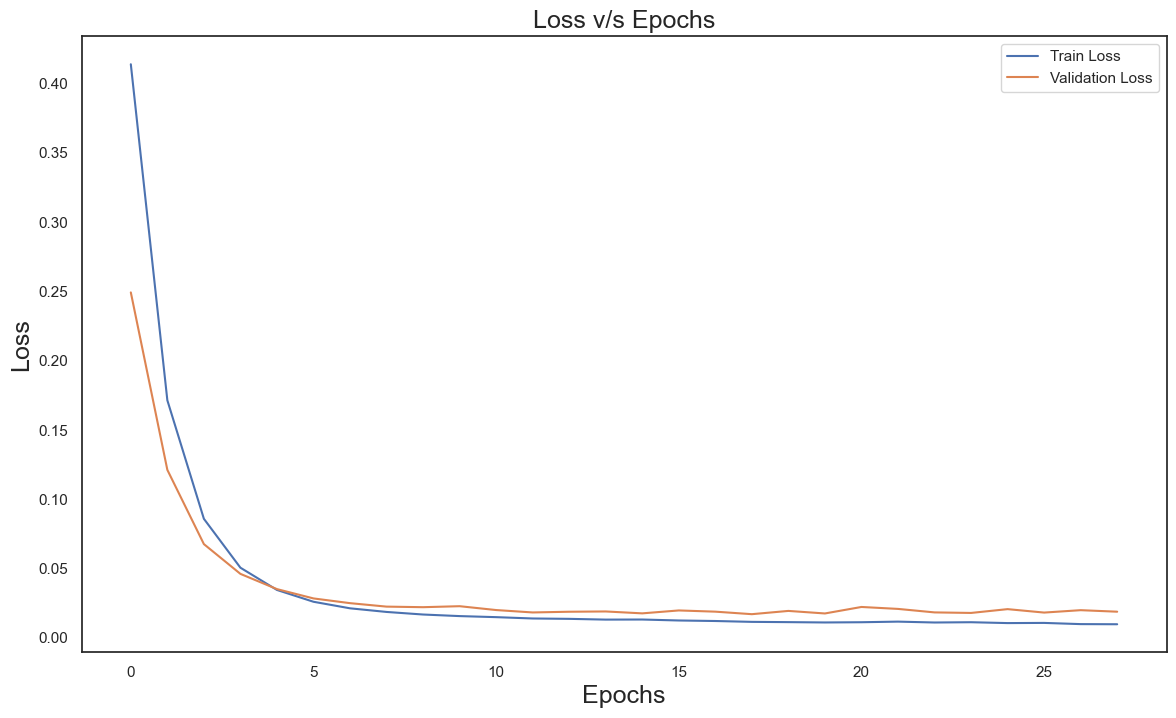

In [45]:
# Plot training & validation loss

plt.figure(figsize=(14, 8))
plt.plot(lstm_Model.history['loss'], label='Train Loss')
plt.plot(lstm_Model.history['val_loss'], label='Validation Loss')
plt.title('Loss v/s Epochs', fontsize=18)
plt.ylabel('Loss',fontsize=18)
plt.xlabel('Epochs',fontsize=18)
plt.legend()
plt.show()

In [46]:
## for the X_train
train_result=model.predict(X_train_seq)
train_result_inverse=scaler.inverse_transform(train_result)
train_result_close=train_result_inverse[:, 3]

53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step


In [47]:
## for the X_test
test_result=model.predict(X_test_seq)
test_result_inverse=scaler.inverse_transform(test_result)
test_result_close=test_result_inverse[:, 3]


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [48]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error
#for close price
print("MAE of close:", mean_absolute_error(y_test_seq[:,3], test_result[:,3]))
print("R² Score of close:", r2_score(y_test_seq[:,3], test_result[:,3]))
print("MSE of close:", mean_squared_error(y_test_seq[:,3], test_result[:,3]))
print("MAPE of close:", mean_absolute_percentage_error(y_test_seq[:,3], test_result[:,3]))

print("RMSE of close price:", np.sqrt(mean_squared_error(y_test_seq[:,3], test_result[:,3])))


MAE of close: 0.04613239393746688
R² Score of close: -0.16941964371029816
MSE of close: 0.005425792008967392
MAPE of close: 0.21669433707898259
RMSE of close price: 0.07365997562426553


In [49]:
#for all price
print("MAE of close:", mean_absolute_error(y_test_seq, test_result))
print("R² Score of close:", r2_score(y_test_seq, test_result))
print("MSE of close:", mean_squared_error(y_test_seq, test_result))
print("MAPE of close:", mean_absolute_percentage_error(y_test_seq, test_result))

print("RMSE of close price:", np.sqrt(mean_squared_error(y_test_seq, test_result)))


MAE of close: 0.10266003637033669
R² Score of close: -2.280634954340231
MSE of close: 0.02491563292193591
MAPE of close: 1.4308366242920814
RMSE of close price: 0.15784686541688406


In [50]:
#for training dataset

print("MAE of Test:", mean_absolute_error(y_test_seq, test_result))
print("R² Score TESt:", r2_score(y_test_seq, test_result))
print("MSE TESt:", mean_squared_error(y_test_seq, test_result))
print("MAPE of Test:", mean_absolute_percentage_error(y_test_seq, test_result))
print("MSE Train:", np.sqrt(mean_squared_error(y_train_seq, train_result)))



MAE of Test: 0.10266003637033669
R² Score TESt: -2.280634954340231
MSE TESt: 0.02491563292193591
MAPE of Test: 1.4308366242920814
MSE Train: 0.10224766634178592


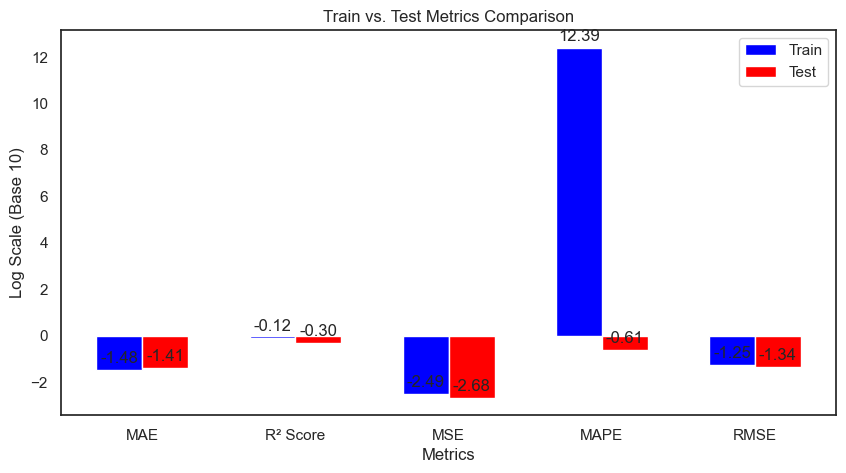

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Metrics values
metrics = ['MAE', 'R² Score', 'MSE', 'MAPE', 'RMSE']
train_values = [0.03285, 0.7509, 0.00320, 2471872178591.562, 0.05663]
test_values = [0.03900, 0.4985, 0.00211, 0.2478, 0.04595]

# Fix scale issue (log scale for MAPE due to huge difference)
log_train_values = np.log10(train_values)
log_test_values = np.log10(test_values)

# Bar plot
x = np.arange(len(metrics))
width = 0.3  # Bar width

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, log_train_values, width, label='Train', color='blue')
bars2 = ax.bar(x + width/2, log_test_values, width, label='Test', color='red')

# Labels
ax.set_xlabel('Metrics')
ax.set_ylabel('Log Scale (Base 10)')
ax.set_title('Train vs. Test Metrics Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Show values on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', 
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # Offset
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()


In [52]:
X_test_seq.shape, X_train_seq.shape, y_test_seq.shape, y_train_seq.shape

((132, 60, 19), (1667, 60, 19), (132, 19), (1667, 19))

In [53]:
X_all = np.concatenate((X_train_scaled, X_test_scaled), axis=0)

X_all.shape

(1919, 19)

In [54]:
# Function to predict future days recursively (all 8 features)
def predict_future_multivariate(model, data, scaler, n_steps, future_days):
    predicted = []
    current_sequence = data[-n_steps:]  # Last window of data

    for _ in range(future_days):
        prediction = model.predict(current_sequence.reshape(1, n_steps, X_all.shape[1]), verbose=0)
        predicted.append(prediction[0])

        # Append predicted row to current sequence for next prediction
        current_sequence = np.vstack([current_sequence[1:], prediction])

    # Inverse transform all predicted data (8 features)
    predicted_array = np.array(predicted)
    predicted_prices = scaler.inverse_transform(predicted_array)
    return predicted_prices

In [55]:
# Predict next 30 days
n_steps = 60
future_days = 150
future_prices = predict_future_multivariate(model, X_all, scaler, n_steps, future_days)

In [56]:
n_steps

60

In [57]:
# Plot actual vs future Close prices
actual_close_prices = df['Close'].values

In [58]:
test_result.shape, train_result.shape, future_prices.shape,test_result_close.shape, train_result_close.shape

((132, 19), (1667, 19), (150, 19), (132,), (1667,))

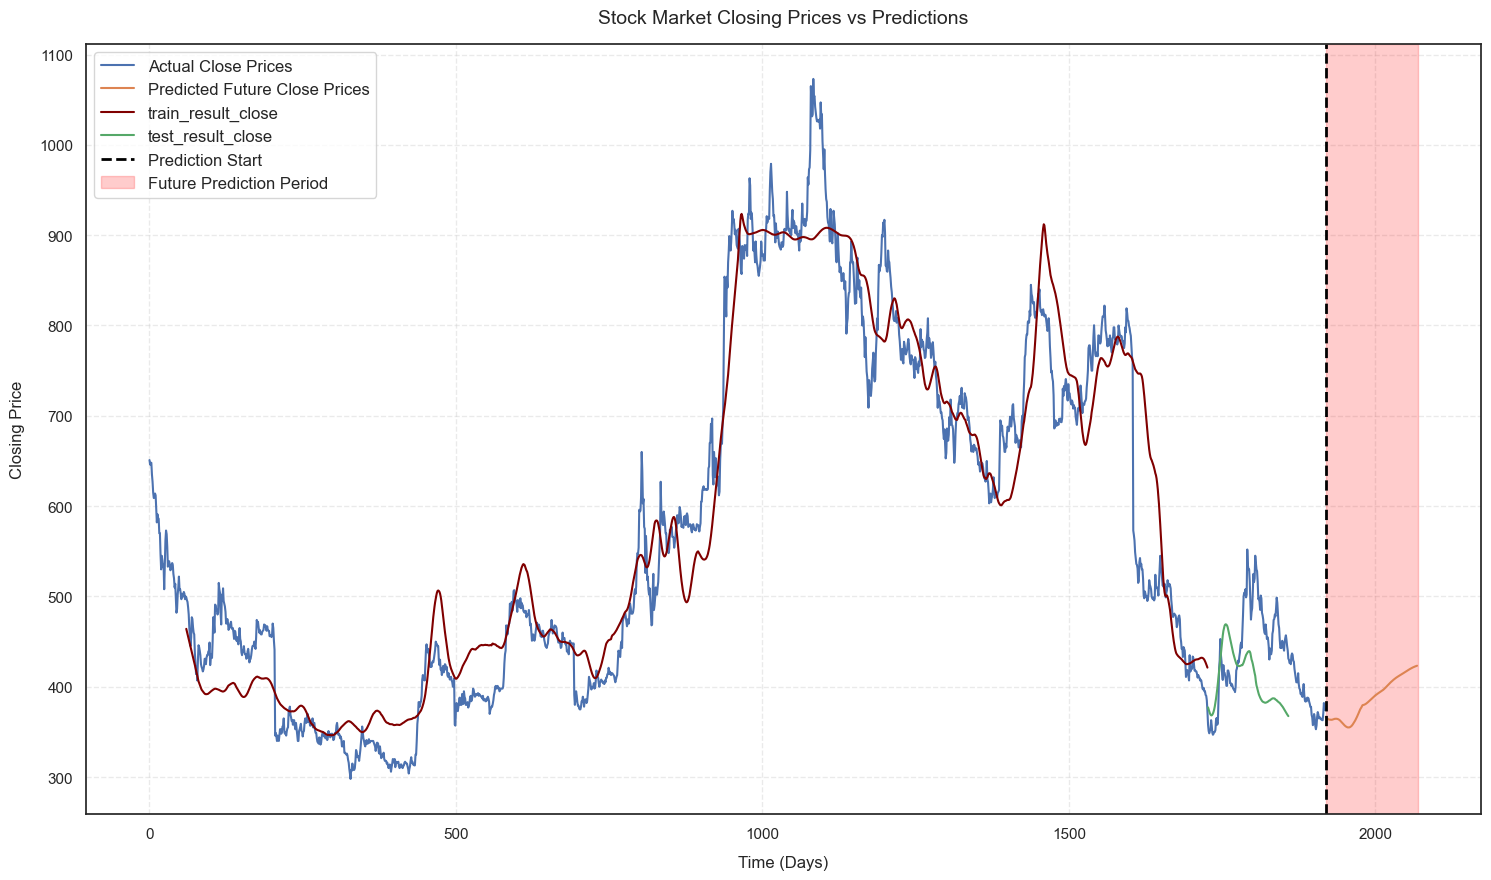

In [59]:
# Plot actual vs future Close prices

actual_close_prices = df['Close'].values
plt.figure(figsize=(18, 10))
plt.plot(actual_close_prices, label='Actual Close Prices')
plt.plot(range(len(actual_close_prices), len(actual_close_prices) + future_days), future_prices[:, 3], label='Predicted Future Close Prices')
plt.plot(range(n_steps, len(train_result_close)+n_steps),train_result_close,label="train_result_close", color="maroon" )
plt.plot(range(len(train_result_close)+n_steps, len(train_result_close)+len(test_result_close)+n_steps),test_result_close,label="test_result_close" )

plt.axvline(x=len(df), color='black', linestyle='--', linewidth=2, label="Prediction Start")

plt.axvspan(len(df), len(df)+future_days, color='red', alpha=0.2, label="Future Prediction Period")
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlabel("Time (Days)", fontsize=12, labelpad=10)
plt.ylabel("Closing Price", fontsize=12, labelpad=10)
plt.title("Stock Market Closing Prices vs Predictions", fontsize=14, pad=15)
plt.legend(fontsize=12, loc="upper left")

In [60]:
# Print predicted future prices (all features for each day)
future_df = pd.DataFrame(future_prices, columns=feature_columns)
future_df

,Open,High,Low,Close,Qty,EPS,PE,RSI9,RSI14,RSI25,MACD,MACDSignal,MACDHist,BollingerUpper,BollingerMiddle,BollingerLower,ATR,Closediff,pchange
0,366.242432,380.790558,372.309357,366.531647,3235.677979,19.385223,37.724007,44.179741,42.415672,41.839630,-7.237155,-11.336259,-0.379723,384.854828,376.080994,363.346832,8.232508,-12.417735,-1.423581
1,365.403473,379.874237,371.259094,365.797577,3416.794678,19.233450,37.618675,44.239697,42.503849,41.903358,-7.178426,-11.221714,-0.399135,383.826324,375.175690,361.925903,8.207097,-12.414507,-1.420819
2,364.564301,378.949768,370.193146,365.127228,3768.932129,19.079828,37.488388,44.336002,42.639008,42.011597,-7.083174,-11.051296,-0.418465,382.782745,374.224213,360.341858,8.182257,-12.372761,-1.411071
3,363.814850,378.133209,369.233093,364.562775,4157.677246,18.938307,37.359707,44.437965,42.780170,42.127060,-6.981786,-10.873614,-0.436405,381.853943,373.357361,358.850006,8.160579,-12.324431,-1.400061
4,363.089081,377.305847,368.311249,364.104523,4719.476562,18.810320,37.212658,44.582111,42.971649,42.291859,-6.840148,-10.634914,-0.451813,380.915375,372.477661,357.238556,8.140530,-12.219131,-1.379957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,406.539734,423.275726,414.523346,422.293152,52769.441406,25.865278,32.943516,53.442028,53.272488,52.458450,1.903236,1.200403,0.080562,431.268524,407.295898,373.914520,10.195838,-2.424987,0.262632
146,406.837616,423.568390,414.840820,422.569733,52797.136719,25.906641,32.943081,53.434795,53.260891,52.448769,1.895790,1.185076,0.082881,431.596161,407.576721,374.257599,10.205986,-2.424797,0.262292
147,407.124756,423.849091,415.148529,422.833008,52809.503906,25.946346,32.944492,53.425190,53.246452,52.436409,1.885977,1.166735,0.085187,431.911499,407.848480,374.597900,10.215432,-2.426617,0.261598
148,407.401978,424.119293,415.447449,423.084167,52807.359375,25.984402,32.947765,53.413303,53.229309,52.421467,1.873830,1.145414,0.087476,432.216064,408.112030,374.935974,10.224222,-2.430621,0.260569


In [61]:
# Save to CSV if needed
# future_df.to_csv(f'{current_time}predicted_future_prices.csv', index=False)

In [62]:
df['Close'].tail(),future_df['Close'].head()

(Date
 2025-02-13    363.0
 2025-02-16    370.7
 2025-02-17    382.0
 2025-02-18    377.0
 2025-02-20    374.5
 Name: Close, dtype: float64,
 0    366.531647
 1    365.797577
 2    365.127228
 3    364.562775
 4    364.104523
 Name: Close, dtype: float32)

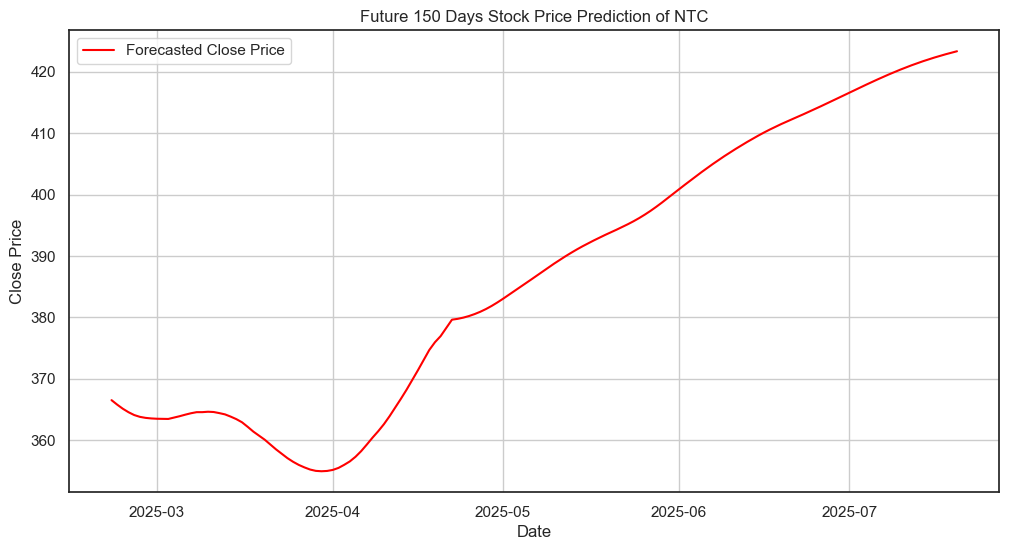

In [63]:
# Plot forecasted values
# Convert to NumPy
future_predictions_close = np.array(future_prices[:, 3])

# Generate future dates correctly
last_date = pd.to_datetime(df.index[-1])  # Get last date from DataFrame index
future_dates = [last_date + pd.Timedelta(days=i) for i in range(1, future_days + 1)]


# Plot forecasted values
plt.figure(figsize=(12, 6))
plt.plot(future_dates, future_predictions_close, label="Forecasted Close Price", color="red")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title(f"Future {future_days} Days Stock Price Prediction of NTC")
plt.legend()
plt.grid()
plt.show()

# # # Print predicted prices
# for date, price in zip(future_dates, future_predictions_close):
#     print(f"Date: {date.date()}, Predicted_Close_Price: {price:.2f}")

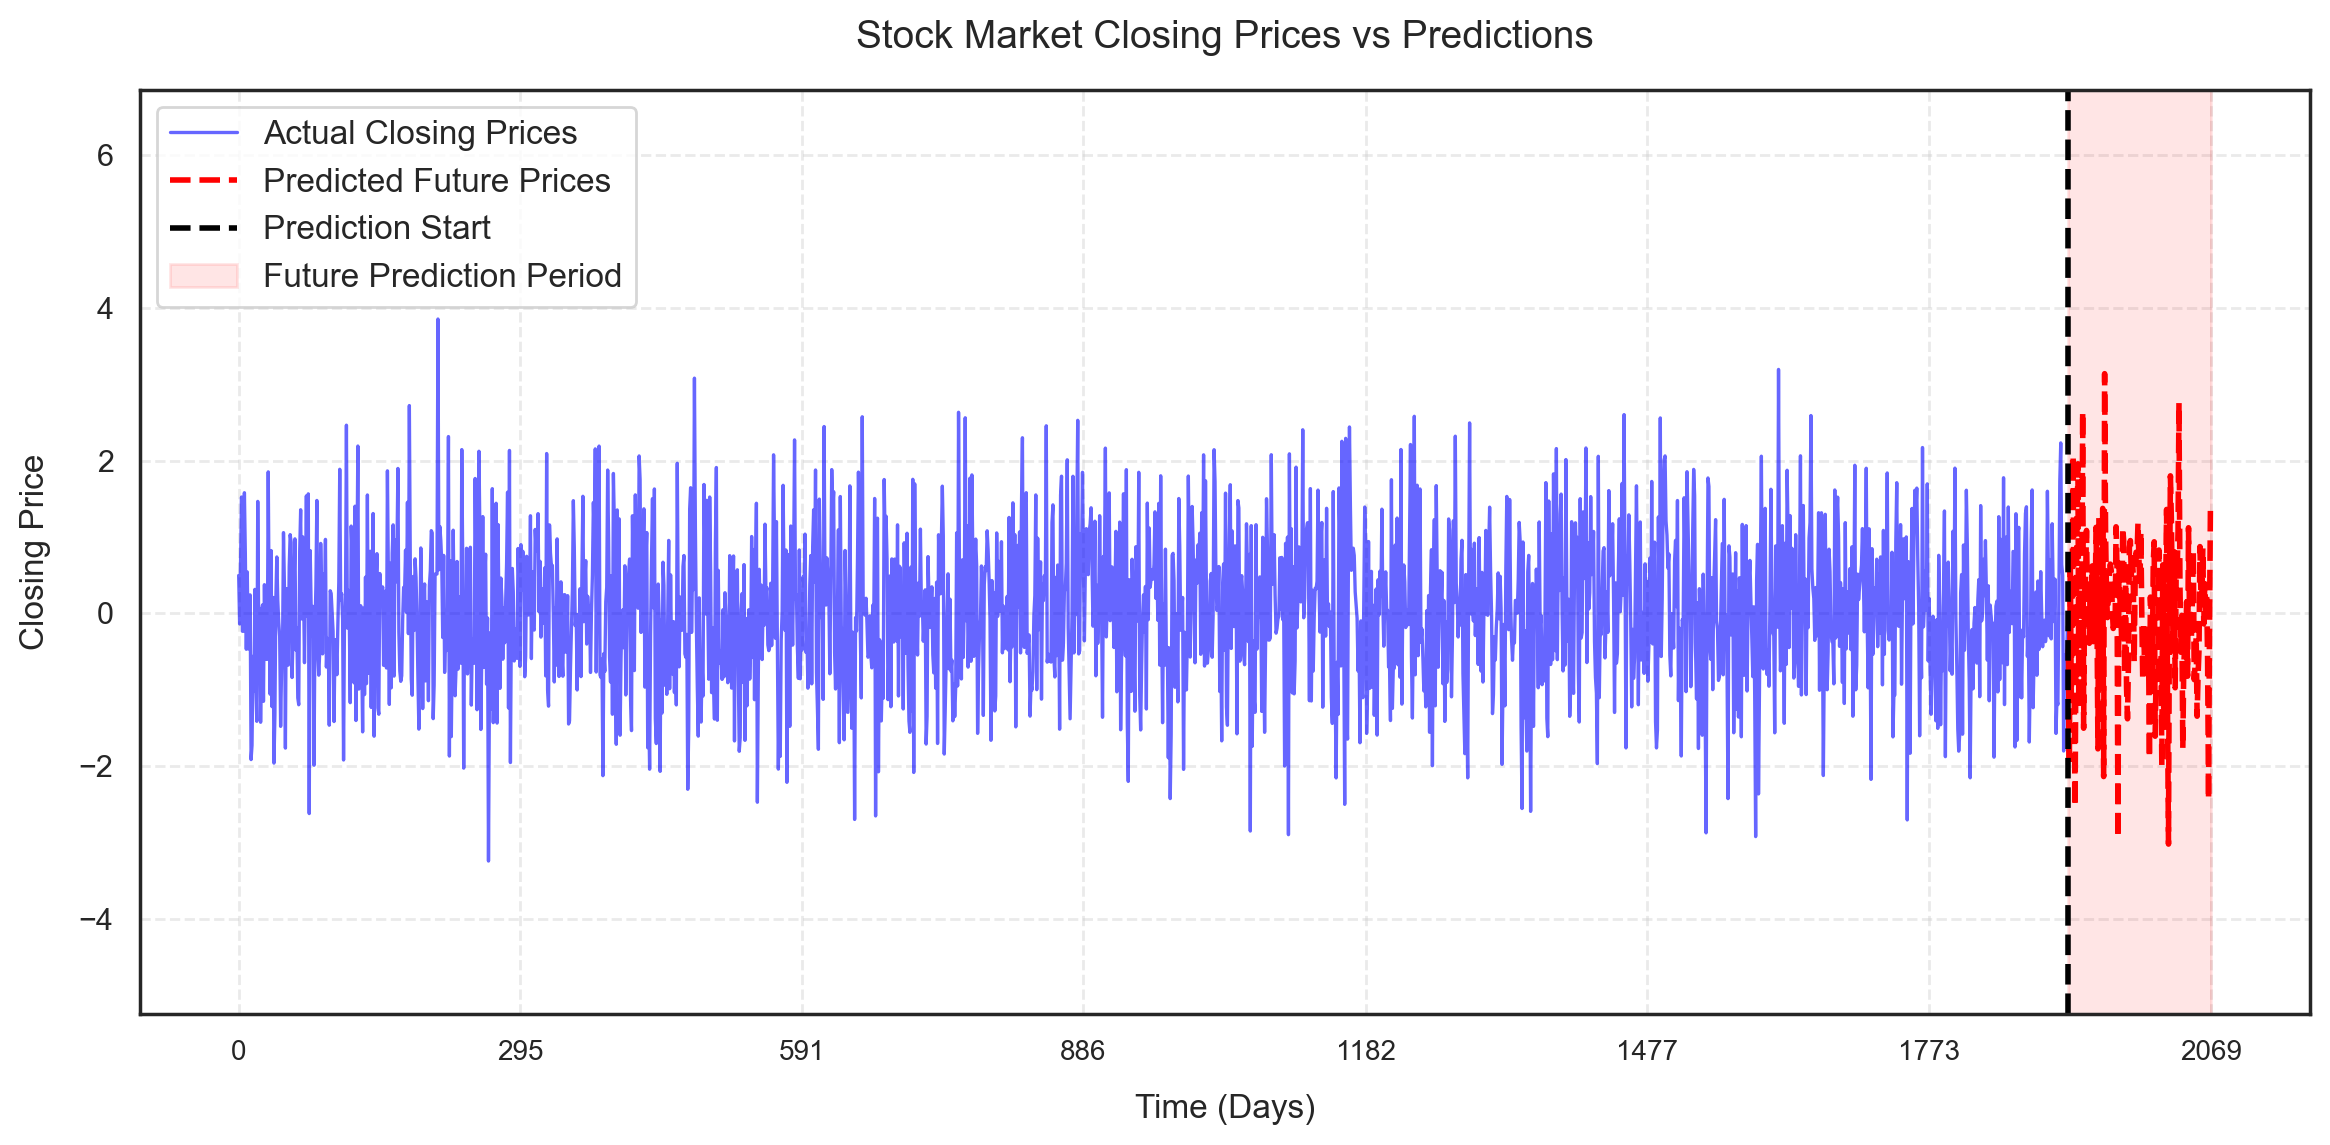

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated Data (Replace with your real data)
dates = np.arange(len(df)+future_days)  # Dates as index
actual_closing_prices = np.random.randn(len(df))  # Less noise in actual prices
predicted_prices = np.random.randn(future_days)  # Smoother predictions

# Create figure with better aspect ratio and higher DPI for clarity
plt.figure(figsize=(14, 6), dpi=200)
# Plot actual closing prices with reduced noise and opacity
plt.plot(dates[:len(df)], actual_closing_prices, label="Actual Closing Prices", 
         color='blue', linewidth=1.2, alpha=0.6)

# Plot predicted prices with a bolder dashed line
plt.plot(dates[len(df):], predicted_prices, label="Predicted Future Prices", 
         color='red', linestyle='dashed', linewidth=2)

# Vertical line to indicate forecast start
plt.axvline(x=len(df), color='black', linestyle='--', linewidth=2, label="Prediction Start")

# Shade the future prediction region
plt.axvspan(len(df), len(df)+future_days, color='red', alpha=0.1, label="Future Prediction Period")

# Adjust Y-axis limits for more price space
plt.ylim(min(actual_closing_prices) - 2, max(actual_closing_prices) + 3)

# Improve X-axis readability
plt.xticks(np.linspace(0, len(df)+future_days, num=8, dtype=int), fontsize=10)

# Labels, Title, and Legend with more spacing
plt.xlabel("Time (Days)", fontsize=12, labelpad=10)
plt.ylabel("Closing Price", fontsize=12, labelpad=10)
plt.title("Stock Market Closing Prices vs Predictions", fontsize=14, pad=15)
plt.legend(fontsize=12, loc="upper left")

# Grid adjustments for better clarity
plt.grid(True, linestyle='--', alpha=0.4)

# Show the improved plot
plt.show()

# for error calculation:

In [65]:
y_predicted=test_result_close[-20:]
print(y_predicted)

[385.1627  384.1767  383.70776 383.03882 382.59412 382.0401  381.189
 380.38028 379.5627  378.59875 377.5889  376.41772 375.26025 374.0162
 372.8201  371.54742 370.49228 369.52933 368.5273  367.5349 ]


In [66]:
dferror=pd.DataFrame(df["Close"].tail(20))
# dferror.reset_index(inplace=True)
dferror.head()

,Close
Date,
2025-01-21,359.0
2025-01-22,369.8
2025-01-23,366.0
2025-01-26,356.5
2025-01-27,353.0


In [67]:
dferror["Predicted"]=y_predicted
dferror["Error"]=abs((dferror["Close"]-dferror["Predicted"])/dferror["Close"]*100)
dferror.tail(20)

,Close,Predicted,Error
Date,,,
2025-01-21,359.0,385.162689,7.287657
2025-01-22,369.8,384.176697,3.887695
2025-01-23,366.0,383.707764,4.838187
2025-01-26,356.5,383.038818,7.444269
2025-01-27,353.0,382.594116,8.383602
2025-01-28,357.0,382.040100,7.014034
2025-02-02,367.0,381.188995,3.866211
2025-02-03,372.0,380.380280,2.252763
2025-02-04,369.3,379.562714,2.778964


In [68]:
import numpy as np
AvgError=np.mean(dferror["Error"])
AvgError

np.float64(3.7898174512664475)

In [69]:
dferror.to_csv("Technicalsnsfuture_df.csv", index=False)